#Actividad Autonoma 6: Descubrimiento de conocimiento: reglas de asociación y detección de anomalías.

##Paso 1: Ubicación y selección de la fuente

In [ ]:
#Cargar del conjunto de datos
#Cargar del conjunto de datos
import pandas as pd

try:
    from google.colab import files
    uploaded = files.upload()
    nombre_archivo = next(iter(uploaded))
except ImportError:
    nombre_archivo = '../data/market.csv'  # ajusta el nombre según tu dataset

df = pd.read_csv(nombre_archivo, sep=';')
print("Archivo cargado correctamente")

Saving market.csv to market.csv
Archivo cargado correctamente


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Bread        464 non-null    int64
 1   Honey        464 non-null    int64
 2   Bacon        464 non-null    int64
 3   Toothpaste   464 non-null    int64
 4   Banana       464 non-null    int64
 5   Apple        464 non-null    int64
 6   Hazelnut     464 non-null    int64
 7   Cheese       464 non-null    int64
 8   Meat         464 non-null    int64
 9   Carrot       464 non-null    int64
 10  Cucumber     464 non-null    int64
 11  Onion        464 non-null    int64
 12  Milk         464 non-null    int64
 13  Butter       464 non-null    int64
 14  ShavingFoam  464 non-null    int64
 15  Salt         464 non-null    int64
 16  Flour        464 non-null    int64
 17  HeavyCream   464 non-null    int64
 18  Egg          464 non-null    int64
 19  Olive        464 non-null    int64
 20  Shampoo   

In [ ]:
# Identificación de columnas/fillas con valores faltantes

print("\nValores faltantes por columna:")
#df.isnull().sum()
#Permite conocer cuantos valores nulos hay en cada columna
print(df.isnull().sum())

print(" ")
#Confirmación
df.isnull().values.any()   # Devuelve True si existe algún nulo, False si no



Valores faltantes por columna:
Bread          0
Honey          0
Bacon          0
Toothpaste     0
Banana         0
Apple          0
Hazelnut       0
Cheese         0
Meat           0
Carrot         0
Cucumber       0
Onion          0
Milk           0
Butter         0
ShavingFoam    0
Salt           0
Flour          0
HeavyCream     0
Egg            0
Olive          0
Shampoo        0
Sugar          0
dtype: int64
 


np.False_

In [ ]:
# --- IDENTIFICACIÓN DE ESPACIOS EN BLANCO ---
print("\nConteo de espacios en blanco ocultos (como texto ' '):")
# Comparamos cada celda con un espacio y sumamos los resultados por columna
espacios_blanco = (df == ' ').sum()
print(espacios_blanco[espacios_blanco > 0])


Conteo de espacios en blanco ocultos (como texto ' '):
Series([], dtype: int64)


##Paso 2: Minería de reglas de asociación

In [ ]:
#Para aplicar apriori
# Convertir a formato booleano para Apriori
df_bool = df.astype(bool)

In [ ]:
df_bool.head()

,Bread,Honey,Bacon,Toothpaste,Banana,Apple,Hazelnut,Cheese,Meat,Carrot,...,Milk,Butter,ShavingFoam,Salt,Flour,HeavyCream,Egg,Olive,Shampoo,Sugar
0,True,False,True,False,True,True,True,False,False,True,...,False,False,False,False,False,True,True,False,False,True
1,True,True,True,False,True,True,True,False,False,False,...,True,True,False,False,True,False,False,True,True,False
2,False,True,True,True,True,True,True,True,True,False,...,True,False,True,True,True,True,True,False,False,True
3,True,True,False,True,False,True,False,False,False,False,...,True,False,False,False,True,False,True,True,True,False
4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Obtener itemsets frecuentes (soporte mínimo del 2%)
frequent_itemsets = apriori(df_bool, min_support=0.02, use_colnames=True)

# 2. Generar las reglas filtrando por Lift mayor o igual a 1.0
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# 3. Limpiar el formato frozenset de antecedentes y consecuentes para mejor lectura
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

# 4. Ordenar reglas por Lift descendente y seleccionar métricas clave
rules_sorted = rules.sort_values(by='lift', ascending=False)
resultado = rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

# Mostrar las 10 principales reglas
print(resultado.head(10))

                                  antecedents  \
782179                      Cheese, Egg, Meat   
782030  Carrot, Honey, Hazelnut, Bacon, Apple   
782101         Apple, Bacon, Hazelnut, Carrot   
782088              Meat, Cheese, Egg, Carrot   
782121          Honey, Bacon, Hazelnut, Apple   
782108               Honey, Cheese, Egg, Meat   
782129               Bacon, Cheese, Egg, Meat   
782080         Honey, Apple, Hazelnut, Carrot   
782091         Meat, Cheese, Hazelnut, Carrot   
782118               Honey, Bacon, Egg, Apple   

                                  consequents   support  confidence      lift  
782179  Carrot, Honey, Hazelnut, Bacon, Apple  0.021552    0.208333  8.055556  
782030                      Cheese, Egg, Meat  0.021552    0.833333  8.055556  
782101               Honey, Cheese, Egg, Meat  0.021552    0.476190  7.619048  
782088          Honey, Bacon, Hazelnut, Apple  0.021552    0.344828  7.619048  
782121              Meat, Cheese, Egg, Carrot  0.021552    0

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


##Paso 3: Detección de anomalías (Outliers)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

#DETECCIÓN DE ANOMALÍAS CON ISOLATION FOREST
# contamination=0.02 define que esperamos aprox. un 2% de registros atípicos
iso_forest = IsolationForest(contamination=0.02, random_state=42)
anomalies = iso_forest.fit_predict(df) # Retorna 1 para Normal y -1 para Anomalía

# Añadir etiquetas al DataFrame para análisis posterior
df_analysis = df.copy()
df_analysis['Anomaly'] = np.where(anomalies == -1, 'Anomalía', 'Normal')
df_analysis['Basket_Size'] = df.sum(axis=1)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

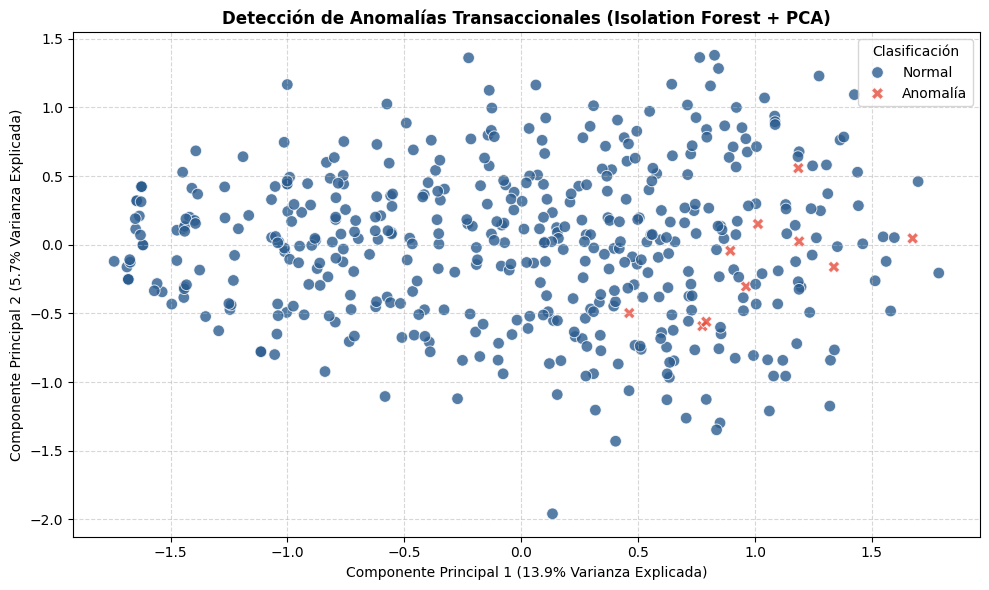

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
from sklearn.decomposition import PCA

#REDUCCIÓN DE DIMENSIONALIDAD CON PCA A 2 COMPONENTES
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df)

# Construir DataFrame para la gráfica
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Estado'] = df_analysis['Anomaly'].values

# 4. VISUALIZACIÓN GRÁFICA DE REGISTROS ATÍPICOS
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Estado',
    style='Estado',
    palette={'Normal': '#2b5c8f', 'Anomalía': '#e74c3c'},
    markers={'Normal': 'o', 'Anomalía': 'X'},
    s=70,
    alpha=0.8,
    data=df_pca
)

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.title('Detección de Anomalías Transaccionales (Isolation Forest + PCA)', fontsize=12, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({var_pc1:.1f}% Varianza Explicada)')
plt.ylabel(f'Componente Principal 2 ({var_pc2:.1f}% Varianza Explicada)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Clasificación', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
#INSPECCIÓN DE LOS REGISTROS ATÍPICOS ENCONTRADOS
outlier_samples = df_analysis[df_analysis['Anomaly'] == 'Anomalía']
print(f"Total de registros atípicos identificados: {len(outlier_samples)}")
print("\nEstadísticas del tamaño de canasta (Normal vs Anomalía):")
print(df_analysis.groupby('Anomaly')['Basket_Size'].describe())

Total de registros atípicos identificados: 10

Estadísticas del tamaño de canasta (Normal vs Anomalía):
          count       mean       std   min   25%   50%    75%   max
Anomaly                                                            
Anomalía   10.0  13.900000  1.595131  11.0  13.0  14.0  14.75  17.0
Normal    454.0   8.674009  3.947714   1.0   5.0   9.0  12.00  17.0
